## Introdução e descrição das variáveis

O conjunto de dados utilizado neste estudo contém informações sobre **acidentes ocorridos em rodovias federais no Estado da Paraíba. Essas informações incluem características relacionadas ao momento do acidente, localização, condições da via, características do veículo envolvido e dados sobre os indivíduos participantes**. A análise dessas variáveis permite compreender melhor os fatores associados à ocorrência e à gravidade dos acidentes, possibilitando o desenvolvimento de modelos estatísticos ou de aprendizado de máquina, como o método **K-Nearest Neighbors (KNN)**, para identificar padrões e realizar previsões.

As variáveis presentes no conjunto de dados são descritas a seguir:

* **pesid**: identificador único associado ao indivíduo envolvido no acidente.
* **data_inversa**: data em que o acidente ocorreu.
* **dia_semana**: dia da semana correspondente à data do acidente.
* **horario**: horário aproximado da ocorrência do acidente.
* **br**: número da rodovia federal onde ocorreu o acidente.
* **km**: quilômetro da rodovia em que o acidente foi registrado.
* **municipio**: município onde ocorreu o acidente.
* **causa_acidente**: causa presumida do acidente, como falha do condutor, ultrapassagem indevida ou presença de objeto na via.
* **tipo_acidente**: classificação do acidente de acordo com sua natureza, por exemplo colisão frontal, colisão traseira ou tombamento.
* **tipo_envolvido**: papel da pessoa no acidente, como condutor, passageiro ou pedestre.
* **estado_fisico**: condição física da pessoa após o acidente, podendo indicar, por exemplo, ileso, ferido leve ou ferido grave.
* **idade**: idade do indivíduo envolvido no acidente.
* **sexo**: sexo do indivíduo.
* **ilesos**: número de pessoas que não sofreram ferimentos.
* **feridos_leves**: número de pessoas que sofreram ferimentos leves.
* **feridos_graves**: número de pessoas que sofreram ferimentos graves.
* **mortos**: número de vítimas fatais associadas ao acidente.
* **latitude**: coordenada geográfica que indica a posição do acidente no sentido norte-sul.
* **longitude**: coordenada geográfica que indica a posição do acidente no sentido leste-oeste.

Essas variáveis permitem analisar diferentes dimensões dos acidentes, incluindo fatores temporais, espaciais e características dos envolvidos. A partir dessas informações, torna-se possível aplicar técnicas de modelagem estatística e de aprendizado de máquina para investigar padrões de ocorrência e fatores associados à gravidade dos acidentes.


In [107]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_excel("acidentes2026_PB.xlsx")
df = df.dropna(how = 'all')
print(df.head())

     pesid data_inversa    dia_semana   horario   br      km  municipio  \
0  1663875   2026-01-01  quinta-feira  04:04:00  153   155.0  ARAGUAINA   
1  1663872   2026-01-01  quinta-feira  06:40:00  262   146.1  RIO CASCA   
2  1663827   2026-01-01  quinta-feira  06:58:00  101   193.0    BIGUACU   
3  1663828   2026-01-01  quinta-feira  07:05:00   60    23.0   BRASILIA   
4  1663884   2026-01-01  quinta-feira  06:17:00  163  1044.0     MATUPA   

                             causa_acidente                  tipo_acidente  \
0  Objeto estático sobre o leito carroçável                     Tombamento   
1                         Condutor Dormindo                Colisão frontal   
2  Reação tardia ou ineficiente do condutor  Colisão lateral mesmo sentido   
3  Reação tardia ou ineficiente do condutor               Colisão traseira   
4                    Transitar na contramão                Colisão frontal   

   Unnamed: 9  ... tipo_envolvido estado_fisico idade       sexo ilesos  \
0    

## variáveis selecionadas

In [112]:
vars_modelo = [
    "sexo",
    "tipo_envolvido",
    "tipo_acidente",
    "condicao_metereologica",
    "fase_dia",
    "estado_fisico",
    "classificacao_acidente"
]

df_modelo = df[vars_modelo]; df_modelo = df_modelo.dropna(); df_modelo.head()

,sexo,tipo_envolvido,tipo_acidente,condicao_metereologica,fase_dia,estado_fisico,classificacao_acidente
1,Masculino,Condutor,Colisão frontal,Céu Claro,Pleno dia,Ileso,Com Vítimas Feridas
2,Masculino,Condutor,Colisão lateral mesmo sentido,Nublado,Amanhecer,Ileso,Com Vítimas Feridas
3,Masculino,Condutor,Colisão traseira,Céu Claro,Pleno dia,Ileso,Com Vítimas Feridas
4,Masculino,Condutor,Colisão frontal,Sol,Amanhecer,Ileso,Com Vítimas Feridas
5,Masculino,Condutor,Colisão com objeto,Céu Claro,Pleno dia,Lesões Leves,Com Vítimas Feridas


## divindo a base em treino e teste e removendo valores missing

In [113]:
X = df_modelo.drop("classificacao_acidente", axis=1); X = X.dropna()
y = df_modelo["classificacao_acidente"]; y = y.dropna()


## tratando as variaveis com mais de 2 níveis

In [114]:
# Seleciona apenas colunas categóricas
categorical_cols = X.select_dtypes(include='object').columns
encoder = OrdinalEncoder()
X[categorical_cols] = encoder.fit_transform(X[categorical_cols])

# Agora cada categoria virou um número inteiro
X.head()


,sexo,tipo_envolvido,tipo_acidente,condicao_metereologica,fase_dia,estado_fisico
1,2.0,1.0,4.0,1.0,3.0,0.0
2,2.0,1.0,5.0,5.0,0.0,0.0
3,2.0,1.0,8.0,1.0,3.0,0.0
4,2.0,1.0,4.0,6.0,0.0,0.0
5,2.0,1.0,3.0,1.0,3.0,2.0


## Gerando dados de treino e teste

🔹 **X_train e y_train** — Fase de treinamento (aprendizado)
Nessa etapa, o modelo recebe as variáveis explicativas (X_train) junto com as respostas corretas (y_train).
É como estudar com o gabarito: o modelo aprende os padrões que relacionam as entradas às saídas.

🔹 **X_test** — Fase de teste (prova)
Aqui, o modelo recebe apenas as variáveis (X_test), sem acesso às respostas.
Ele precisa usar o que aprendeu para fazer previsões, como em uma prova real.

🔹 **y_test** — Gabarito da prova
Após realizar as previsões, comparamos os resultados do modelo com as respostas reais (y_test).
Essa comparação permite avaliar o desempenho e verificar se o modelo realmente aprendeu bem.

In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

## Definindo o número de K a ser utilizado

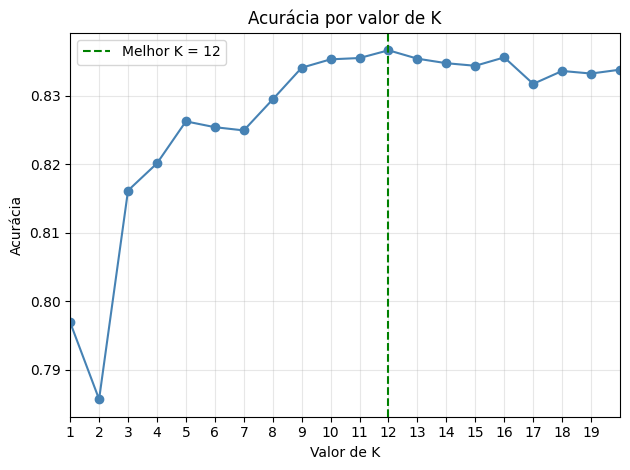

In [116]:

acuracias = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train, y_train, cv=5).mean()
    acuracias.append(score)

melhor_k = acuracias.index(max(acuracias)) + 1
plt.plot(range(1, 21), acuracias, marker='o', color='steelblue')
plt.axvline(x=melhor_k, color='green', linestyle='--', label=f'Melhor K = {melhor_k}')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia')
plt.xticks(range(1,20))
plt.xlim(1,20)
plt.title('Acurácia por valor de K')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ajustando o modelo KNN e vendo algumas estatístyicas importantes

In [117]:

knn = KNeighborsClassifier(n_neighbors=12, metric= 'hamming',weights="distance", leaf_size = 40)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",12
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",40
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'hamming'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Fazendo previsões com base no KNN

In [118]:
y_pred = knn.predict(X_test)

## Avaliando o KNN com metricas de desempenho

In [119]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.841039189784236
                     precision    recall  f1-score   support

 Com Vítimas Fatais       0.72      0.48      0.58       431
Com Vítimas Feridas       0.86      0.96      0.91      3582
        Sem Vítimas       0.69      0.33      0.45       529

           accuracy                           0.84      4542
          macro avg       0.76      0.59      0.64      4542
       weighted avg       0.83      0.84      0.82      4542



O modelo KNN apresentou **acurácia de 0,84**, indicando que 84% das classificações foram feitas corretamente, o que representa um bom desempenho geral.

Analisando por classe, observa-se que **“Com Vítimas Feridas”** teve o melhor resultado, com **recall de 0,96** e **f1-score de 0,91**, mostrando que o modelo consegue identificar muito bem a maioria dos casos dessa categoria. Isso ocorre, em parte, por ser a classe com maior número de observações (3582).

Para a classe **“Com Vítimas Fatais”**, a **precisão de 0,72** indica um nível razoável de acerto quando o modelo faz essa previsão. No entanto, o **recall de 0,48** mostra que menos da metade dos casos reais são corretamente identificados, evidenciando dificuldade em detectar esse tipo de acidente.

Já a classe **“Sem Vítimas”** apresentou desempenho mais fraco, com **recall de 0,33** e **f1-score de 0,45**, indicando que o modelo frequentemente confunde essa categoria com as demais.

A **média macro (f1 = 0,64)** reforça que o modelo não tem desempenho equilibrado entre as classes, enquanto a **média ponderada (f1 = 0,82)** é mais alta devido à influência da classe majoritária.

Em resumo, apesar da boa acurácia, o modelo está **desbalanceado**, com excelente desempenho na classe mais frequente e dificuldades nas classes minoritárias.


## Matrix de confusão do modelo (real x previsto)

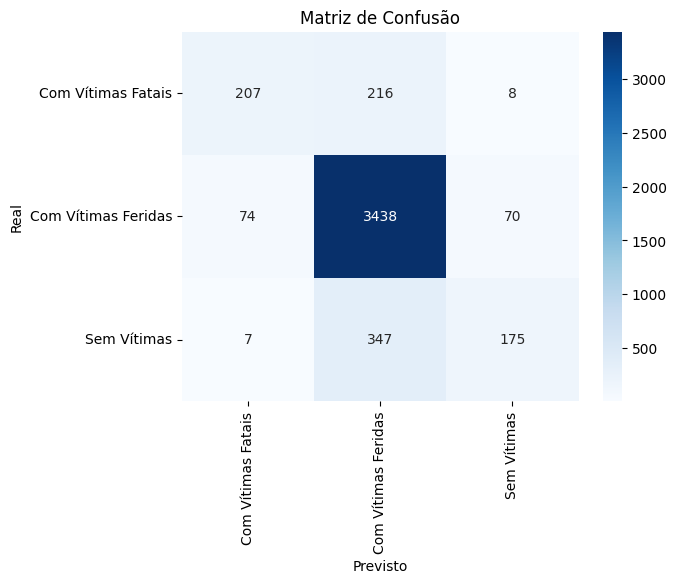

In [120]:
cm = confusion_matrix(y_test, y_pred)
classes = knn.classes_

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

### Interpretação de algumas células

- Diagonal principal (linha = coluna): são os acertos do modelo.

 Acidentes com vitimas Fatais previstas como realmente Acidentes com vitimas Fatais → 207 casos.
 Acidentes com vitimas Feridas previstas como realmente Acidentes com vitimas Feridas → 3438 casos.

- Fora da diagonal: são erros de classificação.

 Acidentes com vitimas Fatais previstas quando na realidade eram acidentes sem vitimas -> 7 casos
 Acidentes com vitimas Fatais previstas quando na realidade Acidentes com vitimas Feridas → 74 casos.